In [3]:
import numpy as np

data = np.loadtxt("/Users/mariaflores/Downloads/04_FPLC_peak_integration/run_001.csv", delimiter=",", skiprows=1)
time = data[:, 0]
signal = data[:, 1]

print(data.shape)
print(time[0], time[-1])
print(signal.min(), signal.max())

(1200, 2)
0.0 60.0
0.078725 1.360949


In [4]:
# Moving to stage 2 of the pipeline...how can we estimate the baseline using only the parts of the signal where there probably isn't a peak without knowing where the peaks are yet
# Step 1 - Build the anchors by chopping the points into equal windows. Window size: 80
window_size = 80
# Reshape to turn the array from 1D to 2D
windows = signal.reshape(-1, window_size)
print(windows.shape)

(15, 80)


In [11]:
# Use aggregation. We know that each row is a window, and we want the lowest value in each row - one number per row means 15 in total
anchor_values = windows.min(axis=1)
print(anchor_values.shape)

# Do the same for the time values...but first reshape and then instead of collapsing the min()...we will do the mean()
window = time.reshape(-1, window_size)
print(window.shape)
# Knowing the shape - (15, 80)...now we can determine our axis to calculate the mean
anchor_times = window.mean(axis=1)
print(anchor_times)

(15,)
(15, 80)
[ 1.97664721  5.97998333  9.98331944 13.98665555 17.98999165 21.99332778
 25.99666389 30.         34.00333611 38.00667223 42.01000835 46.01334445
 50.01668056 54.02001668 58.02335279]


In [12]:
x_known = time
y_known = signal
baseline = np.interp(time, anchor_times, anchor_values)
corrected = signal - baseline
print(corrected)

[0.038072 0.042813 0.041716 ... 0.01736  0.015535 0.016675]


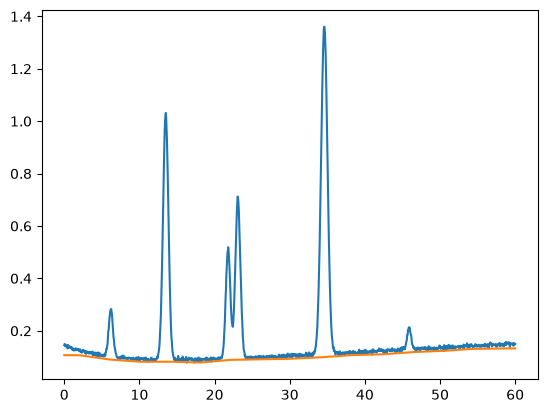

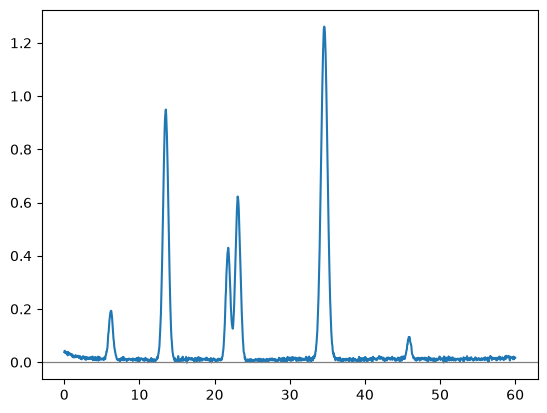

In [16]:
# Now, plot the numbers to check whether the baseline is any good
import matplotlib.pyplot as plt

plt.plot(time, signal)
plt.plot(time, baseline)
plt.show()

# The raw plot shows whether the baseline looks right. Now we want to see whether it is right: between peaks, the corrected traces should sit on zero.
plt.plot(time, corrected)
# plt.axhline -- draws a horizontal line across the whole panel @ a given point y.
plt.axhline(0, color="grey", linewidth=0.9)
plt.show()

In [17]:
# Looking at the flat stretches, they are not quite on zero...so, pick a stretch with no peak in it and ask what the corrected signal averages there
# Trick here: use BOOLEAN MASKING!

quiet = (time > 50) & (time < 56)
print(corrected[quiet].mean())

0.011630441658808121
